# Setup

**Note: Module import issues**

When running the notebook on Google Colab, there might be issues installing the necessary local editable modules, `slicegpt` and `sliced_rag` (i.e. the module is successfully installed, but importing it throws a ModuleNotFoundError).

The following steps usually fix the problem:
1. Run notebook up to the cell where the `slicegpt` module is installed.
2. Click "Restart Session" on the top bar (don't disconnect the runtime)
3. Run notebook up to the cell where our module (`sliced_rag`) is installed.
4. Click "Restart Session" again.
5. Run notebook normally. Both libraries should be successfully imported now.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
try:
  from google.colab import drive
  IN_COLAB = True
except:
  IN_COLAB = False

In [19]:
if IN_COLAB:
  drive.mount('/content/drive')
  %cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/
else:
  %cd ../SliceGPTModifications

!pip install -e .

import slicegpt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/SliceGPTModifications
Obtaining file:///content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/SliceGPTModifications
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for transformercompression (pyproject.toml) ... done
  Created wheel for transformercompression: filename=transformercompression-0.0.1-0.editable-py3-none-any.whl size=5802 sha256=ccf50d04d532dc3c8205a373dca322d46b2bf298a3664e95da5209368d1eef0a
  Stored in directory: /tmp/pip-ephem-wheel-cache-cvi28_n6/wheels/fa/53/4e/3dc845f566a1a5e0e6598609a212dafb7514dbe4ff81527dd7
Successfully built transformercompression
  Att

In [20]:
if IN_COLAB:
  drive.mount('/content/drive')
  %cd /content/drive/MyDrive/TUM/Pratikum/code/sliced_rag
else:
  %cd ../

!pip install -e .
import sliced_rag

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag
Obtaining file:///content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sliced_rag (pyproject.toml) ... done
  Created wheel for sliced_rag: filename=sliced_rag-0.0.1-0.editable-py3-none-any.whl size=1359 sha256=08c818ee3727cd73a80c2bf4c6b332f1c2d74fffe43a5bd5e3a69cb4fae8f544
  Stored in directory: /tmp/pip-ephem-wheel-cache-vufh0ldh/wheels/87/af/6e/7d8e2a554be68c335a7d1be680f600a555227332b6afb36b35
Successfully built sliced_rag
  Attempting uninstall: sliced_rag
    Found existing installatio

In [5]:
if IN_COLAB:
    !pip install -q "peft==0.13.2" "transformers==4.41.0" "lm_eval==0.4.1"

In [21]:
import importlib

In [ ]:
# !rm -f /content/drive/MyDrive/TUM/Pratikum/code/sliced_rag/.git/index.lock

In [ ]:
# %cd /content/drive/MyDrive/TUM/Pratikum/code/sliced_rag
# !git reset
# !git status

In [22]:
import os

BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")

if IN_COLAB:
    os.makedirs(LOG_DIR, exist_ok=True)
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(BASE_EVAL_DIR, exist_ok=True)

In [23]:
import lm_eval
importlib.reload(slicegpt)
importlib.reload(sliced_rag)
# importlib.reload(lm_eval)

<module 'sliced_rag' from '/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag/src/sliced_rag/__init__.py'>

In [9]:
from sliced_rag.evaluation import eval

In [10]:
from lm_eval.tasks import initialize_tasks
initialize_tasks()

# Evaluation

In [24]:
model = "facebook/opt-125m"
model_name = model.replace("/", "-")
datasets = ['wikitext2']
# sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
sparsities = [0.0]

In [ ]:
dir_prefix = "debug_"

MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt125M")

results = None

for dataset in datasets:
  for sparsity in sparsities:
    EVAL_DIR = os.path.join(BASE_EVAL_DIR, f"{dir_prefix}{model_name}_{dataset}")
    os.makedirs(EVAL_DIR, exist_ok=True)

    args = {
        "model": model,
        "sliced_model_path": os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}".replace(".", "p")),
        "sparsity": sparsity,
        "save_dir": EVAL_DIR,
        "tasks": ["coqa"],
        "num_fewshot": 0,
        "batch_size": 64,
        "round_interval": 8,
        "limit": 10,
        "log_samples": True
    }

    results = eval(args)

INFO - Running Evaluation
INFO - Loading sliced facebook/opt-125m from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/wikitext2_s0p00 with sparsity 0.0
INFO - Loading facebook/opt-125m config  from Hugging Face


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


INFO - Loading model done
INFO - Replacing layers
INFO - Replacing layers done
INFO - Fusing layernorm modules
INFO - Fusing layernorm modules done
INFO - Loading sliced model weights from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/wikitext2_s0p00
WARNING - `pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
WARNING - Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
INFO - Selected Tasks: ['coqa']
INFO - num_fewshot has been set to 0 for coqa in its config. Manual configuration will be ignored.
INFO - Building contexts for task on rank 0...
INFO - Task: coqa; document 0; context prompt (starting on next line):
Once upon a time, in a barn near a farm house, there lived a little white kitten named Cotton. Cotton lived high up in a nice war

100%|██████████| 10/10 [00:00<00:00, 18.53it/s]


INFO - Results:
INFO - {'results': {'coqa': {'em,none': 0.06666666666666667, 'em_stderr,none': 0.06666666666666667, 'f1,none': 0.15166666666666667, 'f1_stderr,none': 0.09488296884993522, 'alias': 'coqa'}}, 'configs': {'coqa': {'task': 'coqa', 'dataset_path': 'EleutherAI/coqa', 'training_split': 'train', 'validation_split': 'validation', 'doc_to_text': 'def doc_to_text(doc):\n    # Given a passage p, the conversation history {q1, a1, . . . qi−1, ai−1}\n    # and a question qi, the task is to predict the answer ai\n    doc_text = doc["story"] + "\\n\\n"\n    for q, a in zip_longest(\n        doc["questions"]["input_text"], doc["answers"]["input_text"][:-1]\n    ):  # omit target answer ai\n        question = f"Q: {q}\\n\\n"\n        answer = f"A: {a}\\n\\n" if a is not None else "A:"\n        doc_text += question + answer\n    return doc_text\n', 'doc_to_target': 'def doc_to_target(doc):\n    turn_id = len(doc["questions"]["input_text"])\n    # Returns unique answers and valid alternativ

In [25]:
from sliced_rag.analysis import utils, plotting

In [26]:
!git pull

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 521 bytes | 9.00 KiB/s, done.
From https://github.com/lucas-feijo/SlicedRAG
   b69ea7a..03feb12  main       -> origin/main
Updating b69ea7a..03feb12
Fast-forward
 src/sliced_rag/analysis/utils.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)


In [26]:
df = utils.load_sparsity_eval_results(BASE_EVAL_DIR,
                                      model,
                                      "wikitext2",
                                      ["coqa"],
                                      "coqa")

/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag/src/sliced_rag/analysis/plotting.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

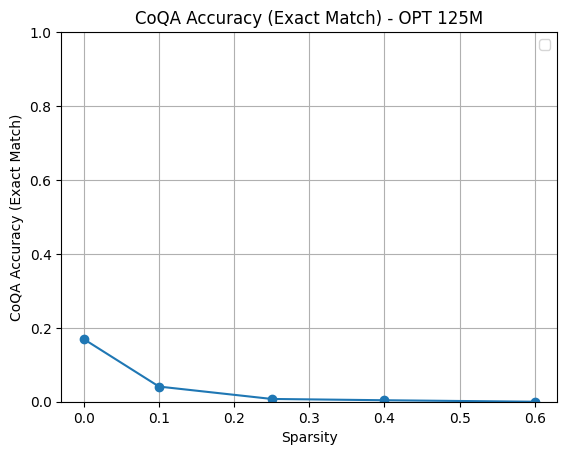

In [28]:
plotting.plot_sparsity_metric(df, "em,none", "CoQA Accuracy (Exact Match)", "OPT 125M", [0, 1])

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

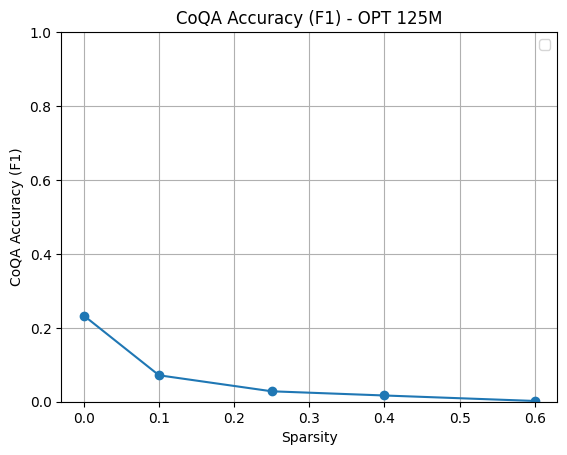

In [29]:
plotting.plot_sparsity_metric(df, "f1,none", "CoQA Accuracy (F1)", "OPT 125M", [0, 1])